# installing dependencies

In [ ]:
!pip install -q transformers==4.49.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.0 MB/s eta 0:00:00


In [ ]:
!pip install -q emoji
!pip install -q PyArabic
!pip install -q arabert
!pip install -q emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 11.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Modules

In [ ]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))
    !nvidia-smi

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Sat Apr  4 09:44:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |            

In [ ]:
import pandas as pd
import numpy as np
from typing import List
from tqdm import tqdm_notebook as tqdm
from sklearn.model_selection import train_test_split
import string
import emoji
import pyarabic.araby as araby
import re

# Creating training datasets

This custom dataset class will help us hold our datasets in a structred manner.
It's not necessary to use it with your own data

In [ ]:
class CustomDataset:
    def __init__(
        self,
        name: str,
        train: List[pd.DataFrame],
        val: List[pd.DataFrame],
        test: List[pd.DataFrame],
        label_list: List[str],
    ):
        """Class to hold and structure datasets.

        Args:

        name (str): holds the name of the dataset so we can select it later
        train (List[pd.DataFrame]): holds training pandas dataframe with 2 columns ["text","label"]
        val (List[pd.DataFrame]): holds validation pandas dataframe with 2 columns ["text","label"]
        test (List[pd.DataFrame]): holds testing pandas dataframe with 2 columns ["text","label"]
        label_list (List[str]): holds the list  of labels
        """
        self.name = name
        self.train = train
        self.val = val
        self.test = test
        self.label_list = label_list

In [ ]:
# This will hold all the downloaded and structred datasets
all_datasets= []
DATA_COLUMN = "Text"
LABEL_COLUMN = "sentiment"

You can choose which ever dataset you like or use your own.
At this stage we don't do any preprocessing on the text, this is done later when loading the text.

## Sentiment Data

In [ ]:
data = pd.read_csv('train_all.csv')
data = data[[DATA_COLUMN, LABEL_COLUMN]]

data.columns = [DATA_COLUMN, LABEL_COLUMN]
print(data[LABEL_COLUMN].value_counts())

sentiment
neutral     16289
negative     3890
positive     3778
Name: count, dtype: int64


In [ ]:
data.shape

(23957, 2)

In [ ]:
print(data[LABEL_COLUMN].value_counts())

sentiment
neutral     16289
negative     3890
positive     3778
Name: count, dtype: int64


## Preprocessing

In [ ]:
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace(r'[^\w\s]+', '')
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace("\s+", " ", regex=True)

data.head()

In [ ]:
arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations

def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("گ", "ك", text)
    return text


In [ ]:
data[DATA_COLUMN] = data[DATA_COLUMN].apply(normalize_arabic)

data.head()

,Text,sentiment
48348,ياحبّي المغرور ياللي دِفاك شعور رد القمر للنور...,positive
47523,من شدة حبك له تتمنى لو ان الاسى ياكلك باكملك و...,positive
2695,يالليل يا جامع على الود قلبين,neutral
54022,حفلة اكثر من رائعة ستقام في جوهرة جدة كبيرة وج...,positive
7247,لا امتلك تعريفا واضحا للاهاب بس طالما جامعة ال...,neutral


In [ ]:
def data_cleaning(text):
    """Clean and preprocess text data.
    Args:
        text (pd.Series): A pandas Series containing text data to be cleaned.
    Returns:
        pd.Series: A pandas Series with the cleaned text data.

    Cleaning Steps:
    - Removes emojis and special characters like '\x89Û_', '&amp', etc.
    - Replaces consecutive dots with an empty string.
    - Removes '#' symbol from text.
    - Removes user names starting with '@'.
    - Removes URLs starting with 'http' or 'https'.
    - Remove diacritics.
    - Remove English.
    - Removes extra whitespaces between words.

    """
    clean = text
    # Replace consecutive dots with an empty string
    pattern = re.compile('\\.+?(?=\B|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Replace '\x89Û_' with a whitespace
    pattern = re.compile('\x89Û_')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Replace newline characters with a whitespace
    pattern = re.compile('\\n')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Remove '#' symbol from text
    clean = clean.apply(lambda r: r.replace('#', ''))
    # Remove '_' symbol from text
    pattern = re.compile('_')
    clean = clean.apply(lambda r: re.sub(pattern, ' ', r))
    # Replace user names with '@'
    pattern = re.compile('@[a-zA-Z0-9\_]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='@'))
    # Remove URLs
    pattern = re.compile('https?\S+(?=\s|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='www'))
    # Remove emojis
    clean = clean.apply(lambda r: emoji.replace_emoji(r, replace=""))
    # Remove diacritics
    clean = clean.apply(lambda r: araby.strip_diacritics(r))
    # Remove English
    pattern = re.compile(r'[a-zA-Z]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Remove extra whitespaces
    clean = clean.apply(lambda r: ' '.join(r.split()))  # Remove extra whitespaces between words

    return clean

In [ ]:
data[DATA_COLUMN] = data_cleaning(data[DATA_COLUMN])

In [ ]:
def remove_ids(text):
  return text.split("—")[0].strip()

data[DATA_COLUMN] = data[DATA_COLUMN].apply(remove_ids)
data.head()

,Text,sentiment
48348,ياحبي المغرور ياللي دفاك شعور رد القمر للنور و...,positive
47523,من شدة حبك له تتمنى لو ان الاسى ياكلك باكملك و...,positive
2695,يالليل يا جامع على الود قلبين,neutral
54022,حفلة اكثر من رائعة ستقام في جوهرة جدة كبيرة وج...,positive
7247,لا امتلك تعريفا واضحا للاهاب بس طالما جامعة ال...,neutral


In [ ]:
data.dropna(inplace = True)
data = data.drop_duplicates(subset = DATA_COLUMN)

## Split Data

In [ ]:
remove, keep = train_test_split(data,
                               test_size=23957,
                               stratify=data[LABEL_COLUMN],
                               random_state=42)

keep.to_excel('Used ASAD For Training.xlsx')
keep = keep.reset_index(drop = True)

keep.head()

In [ ]:
keep = pd.read_excel('Used ASAD For Training.xlsx')

In [ ]:
train, temp = train_test_split(keep,
                               test_size=0.3,
                               stratify=keep[LABEL_COLUMN],
                               random_state=42)

val, test = train_test_split(temp,
                             test_size=0.5,
                             stratify=temp[LABEL_COLUMN],
                             random_state=42)

In [ ]:
train_indecies = train.index.values
val_indecies = val.index.values
test_indecies = test.index.values


# Create dictionary from lists of different lengths
data = {
    'train': train_indecies,
    'val': val_indecies,
    'test': test_indecies
}

# Use zip_longest to fill missing values with NaN
max_len = max(len(train_indecies), len(val_indecies), len(test_indecies))
indecies = pd.DataFrame({k: pd.Series(v, dtype='float') for k, v in data.items()})

indecies = pd.DataFrame({
    'train': pd.Series(train_indecies),
    'val': pd.Series(val_indecies),
    'test': pd.Series(test_indecies)
})

indecies.to_csv('Train-Val-Test-Indecies-Climate-ASAD.csv', index = False)

In [ ]:
label_list = ['negative', 'neutral', 'positive']

data = CustomDataset("ASAD", train, val, test, label_list)
all_datasets.append(data)

# Trainer

Start the training procedure

In [ ]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import copy

from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoConfig, AutoModelForSequenceClassification,
                          AutoTokenizer, BertTokenizer, Trainer,
                          TrainingArguments)
from transformers.data.processors.utils import InputFeatures

List all the datasets we have

In [ ]:
for x in all_datasets:
  print(x.name)

In [ ]:
# select a dataset
dataset_name = 'ASAD'
model_name = 'aubmindlab/bert-base-arabertv02-twitter'

In [ ]:
for d in all_datasets:
  if d.name==dataset_name:
    selected_dataset = copy.deepcopy(d)
    print('Dataset found')
    break

Dataset found


Create and apply preprocessing using the AraBERT processor

In [ ]:
arabic_prep = ArabertPreprocessor(model_name)

selected_dataset.train[DATA_COLUMN] = selected_dataset.train[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.test[DATA_COLUMN] = selected_dataset.test[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.val[DATA_COLUMN] = selected_dataset.val[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))

In [ ]:
# Sanity check on the dataset
list(selected_dataset.train[DATA_COLUMN][0:10])

['@ الله يرحمه ويجعل مثواه الجنه الله يلهمك الصبر ويجبر خاطرك',
 'الجنادرية 33 مفروض الدخول بفلوس اغلبهم من لحوج البدو و تزاحم',
 '@ ياليت تسمحوا لتطبيقات ثانية بالتوصيل غير هنقرستيشن لان تطبيقهم داائما وكل وقت المطاعم فيه مشغولة وما نقدر نطلب 😭',
 '@ السلام عليكم نعاني من عدم الرد او الاستجابه من وزاره المياه الاحساء',
 'بنات عيادات الاستشاريون في جدة عندهم عرض يخلص يوم الخميس على عملية تصحيح النظر هيا ب 7 الاف بس العرض يسوونها ب 4700 الحق ما تلحق',
 'ايش اسم امام جامع الامام احمد بن حنبل بحي الروضة ؟ و هل له تلاوات في الانترنت ؟',
 'فرحة الميت في قبره لا تصدق عندما يصله دعاء من اهل الدنيا اللهم ارحمهم تحت الارض ويوم العرض وارحمنا اذا صرنا الى ما صاروا اليه',
 'يقول خالد الفيصل : اتصبر واقول اني على البعد قاوي والله اعلم بقلب فيه الاشواق حيه 💕 💕 💕',
 '@ السلام عليكم انا فقدت كلمة السر الخاصه ب خدماتي التطبيق والجوال المسجل عليه رسائل الاسترجاع ليس معي الان ماذا افعل',
 'اتذكرت يوم فتحوا الدفتر دا للاضراب اليومين داك']

Now we need to check the tokenized sentence length to decide on the maximum sentence length value

In [1]:
tok = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/476 [00:00<?, ?B/s]
vocab.txt: 0.00B [00:00, ?B/s]
tokenizer.json: 0.00B [00:00, ?B/s]
special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Training Sentence Lengths: 


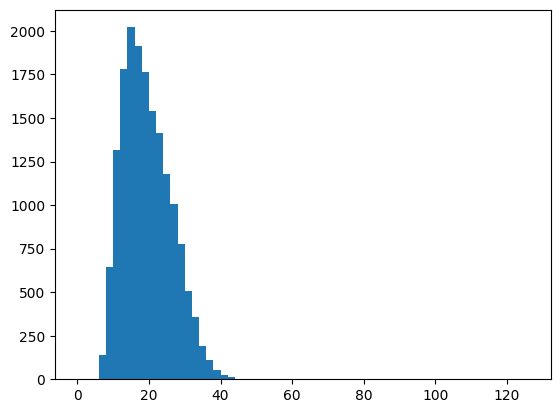

Testing Sentence Lengths: 


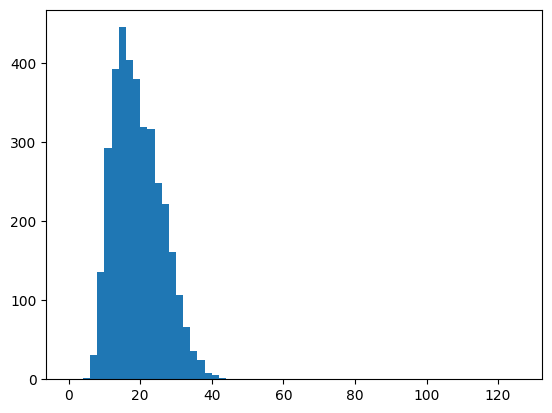

In [ ]:
print("Training Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.train[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

print("Testing Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.test[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

Let's select 100 as our maximum sentence length, and check how many sequences will be truncated

In [ ]:
max_len = 128

In [ ]:
print("Truncated training sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

print("Truncated testing sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

Truncated training sequences:  0
Truncated testing sequences:  0


8 out of ~4000 for testing isn't bad

Now let's create a classification dataset to load the data

In [ ]:
class ClassificationDataset(Dataset):
    def __init__(self, text, target, model_name, max_len, label_map):
      super(ClassificationDataset).__init__()
      """
      Args:
      text (List[str]): List of the training text
      target (List[str]): List of the training labels
      tokenizer_name (str): The tokenizer name (same as model_name).
      max_len (int): Maximum sentence length
      label_map (Dict[str,int]): A dictionary that maps the class labels to integer
      """
      self.text = text
      self.target = target
      self.tokenizer_name = model_name
      self.tokenizer = AutoTokenizer.from_pretrained(model_name)
      self.max_len = max_len
      self.label_map = label_map


    def __len__(self):
      return len(self.text)

    def __getitem__(self,item):
      text = str(self.text[item])
      text = " ".join(text.split())

      inputs = self.tokenizer(
          text,
          max_length=self.max_len,
          padding='max_length',
          truncation=True
      )
      return InputFeatures(**inputs,label=self.label_map[self.target[item]])

In [ ]:
label_map = { v:index for index, v in enumerate(selected_dataset.label_list) }
print(label_map)

train_dataset = ClassificationDataset(
    selected_dataset.train[DATA_COLUMN].to_list(),
    selected_dataset.train[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )
val_dataset = ClassificationDataset(
    selected_dataset.val[DATA_COLUMN].to_list(),
    selected_dataset.val[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )

{'negative': 0, 'neutral': 1, 'positive': 2}


Check the dataset output

In [ ]:
print(next(iter(train_dataset)))

InputFeatures(input_ids=[2, 37, 647, 24464, 17987, 2052, 4709, 1025, 195, 647, 38676, 209, 11686, 5852, 183, 22514, 209, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], attention_mask=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], token_type_ids=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Create a function that return a pretrained model ready to do classification

In [ ]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, return_dict=True, num_labels=len(label_map))

Define whatever metric you want here

In [ ]:
def compute_metrics(p): #p should be of type EvalPrediction
  preds = np.argmax(p.predictions, axis=1)
  assert len(preds) == len(p.label_ids)
  macro_f1 = f1_score(p.label_ids,preds,average='macro')
  macro_precision = precision_score(p.label_ids,preds,average='macro')
  macro_recall = recall_score(p.label_ids,preds,average='macro')
  acc = accuracy_score(p.label_ids,preds)
  return {
      'macro_f1' : macro_f1,
      'macro_precision' : macro_precision,
      'macro_recall' : macro_recall,
      'accuracy': acc
  }

In [ ]:
def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic=True
  torch.backends.cudnn.benchmark = False

# Regular Training

Define our training parameters.
Check the TrainingArguments documentation for more options https://huggingface.co/transformers/main_classes/trainer.html#trainingarguments

In [ ]:
training_args = TrainingArguments(
    output_dir= "./train",
    adam_epsilon = 1e-8,
    learning_rate = 2e-5,
    fp16 = False, # enable this when using V100 or T4 GPU
    per_device_train_batch_size = 32, # up to 64 on 16GB with max len of 128
    per_device_eval_batch_size = 128,
    gradient_accumulation_steps = 2, # use this to scale batch size without needing more memory
    num_train_epochs= 5,
    warmup_ratio = 0,
    do_eval = True,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True, # this allows to automatically get the best model at the end based on whatever metric we want
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    seed = 25,
    report_to = 'none'
  )

set_seed(training_args.seed)

Create the trainer

In [ ]:
trainer = Trainer(
    model = model_init(),
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
#start the training
trainer.train()

Save the model, the tokenizer and the config

In [ ]:
inv_label_map = inv_label_map = { v:k for k, v in label_map.items()}
print(inv_label_map)
trainer.model.config.label2id = label_map
trainer.model.config.id2label = inv_label_map
trainer.save_model("/content/drive/MyDrive/ASAD-AraBERT")
train_dataset.tokenizer.save_pretrained("/content/drive/MyDrive/ASAD-AraBERT")

{0: 'negative', 1: 'neutral', 2: 'positive'}


('/content/drive/MyDrive/Research Projects/Arabic Climate Change Sentiment Analysis/Final Saved Models/output_dir/tokenizer_config.json',
 '/content/drive/MyDrive/Research Projects/Arabic Climate Change Sentiment Analysis/Final Saved Models/output_dir/special_tokens_map.json',
 '/content/drive/MyDrive/Research Projects/Arabic Climate Change Sentiment Analysis/Final Saved Models/output_dir/vocab.txt',
 '/content/drive/MyDrive/Research Projects/Arabic Climate Change Sentiment Analysis/Final Saved Models/output_dir/added_tokens.json',
 '/content/drive/MyDrive/Research Projects/Arabic Climate Change Sentiment Analysis/Final Saved Models/output_dir/tokenizer.json')

## predict using the saved model

In [ ]:
dir = '/content/drive/MyDrive/ASAD-AraBERT'

In [ ]:
from transformers import pipeline
import more_itertools

In [ ]:
pred_df = pd.DataFrame()
pred_df['text'] = selected_dataset.test[DATA_COLUMN].values

In [2]:
pipe = pipeline("sentiment-analysis", model=dir, device=0, return_all_scores =True, max_length=max_len, truncation=True)
preds = []
for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_df[f'preds'] = preds

0it [00:00, ?it/s]


In [ ]:
final_pred = []
for prediction in pred_df['preds']:
    final_pred.append(max(prediction, key=lambda x: x['score'])['label'])

pred_df[f'Final Prediction'] = final_pred
pred_df[f'Final Prediction'].value_counts()

,count
Final Prediction,
neutral,2347
positive,666
negative,581


In [ ]:
class_order1 = ['Negative', 'Neutral', 'Positive']
class_order = ['negative', 'neutral', 'positive']
n_classes = len(class_order)

def extract_scores(row, classes=class_order):
    label_to_score = {d['label']: d['score'] for d in row}
    return [label_to_score.get(cls, 0) for cls in classes]

y_scores = np.array(pred_df['preds'].apply(extract_scores).tolist())

print(y_scores.shape)
print(y_scores[0])

(3594, 3)
[0.48844048 0.41013196 0.10142759]


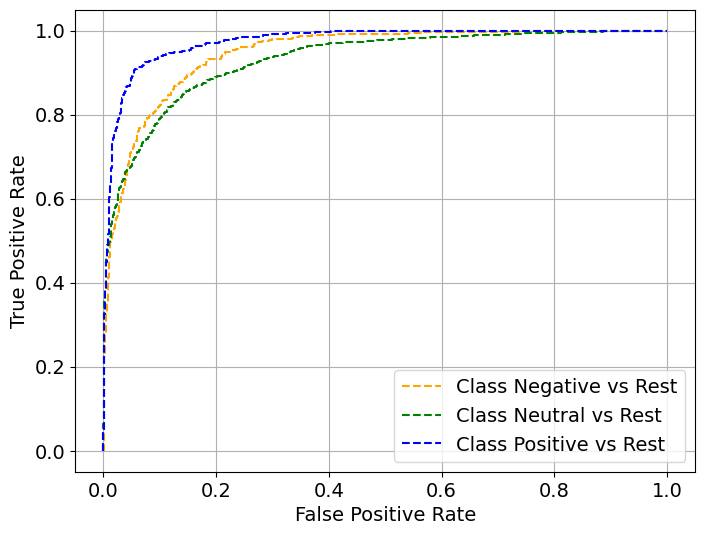

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_true = selected_dataset.test[LABEL_COLUMN]

label_to_index = {label: i for i, label in enumerate(class_order)}
y_true_indices = np.array([label_to_index[label] for label in y_true])

y_true_bin = label_binarize(y_true_indices, classes=range(n_classes))

fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_true_bin[:, i], y_scores[:, i])

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8, 6))
colors = ['orange', 'green', 'blue']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], linestyle='--', color=color, label=f'Class {class_order1[i]} vs Rest')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('Multiclass_ROC_ASADAraBERT_on_ASAD.png', dpi=300, bbox_inches='tight')
plt.show()

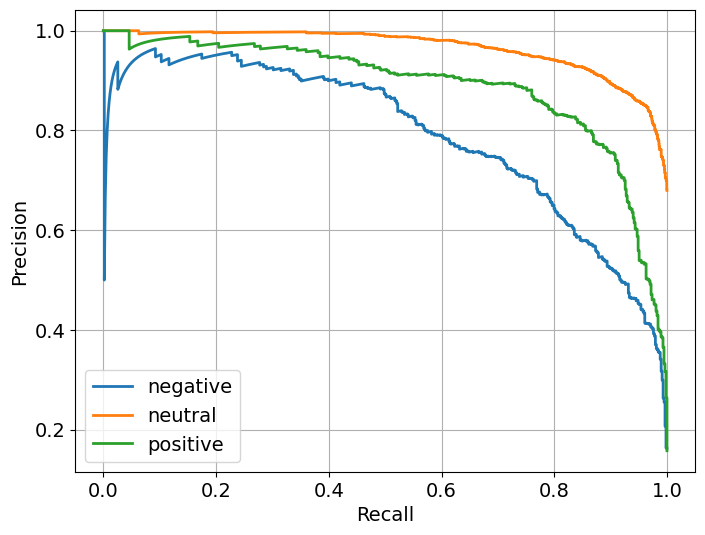

In [ ]:
label_to_index = {label: i for i, label in enumerate(class_order)}
y_true_indices = np.array([label_to_index[label] for label in y_true])

y_true_bin = label_binarize(y_true_indices, classes=range(n_classes))


precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    plt.plot(recall[i], precision[i], lw=2, label=f'{class_order[i]}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.savefig('Multiclass_Precision-Recall Curve_ASADAraBERT_on_ASAD.png', dpi=300, bbox_inches='tight')
plt.grid(True)
plt.show()

In [ ]:
print(classification_report(selected_dataset.test[LABEL_COLUMN],pred_df['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.7246    0.7209    0.7227       584
     neutral     0.9122    0.8764    0.8939      2443
    positive     0.7613    0.8942    0.8224       567

    accuracy                         0.8539      3594
   macro avg     0.7994    0.8305    0.8130      3594
weighted avg     0.8579    0.8539    0.8548      3594



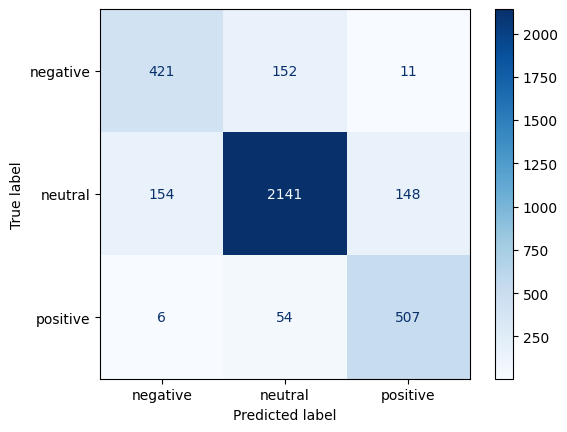

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
   selected_dataset.test[LABEL_COLUMN],pred_df['Final Prediction'], cmap = 'Blues')
plt.savefig("ASAD AraBERT ASAD CM.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
pred_df['true'] = selected_dataset.test[LABEL_COLUMN].values
pred_df.to_excel('AraBERT ASAD ASAD.xlsx', index = False)

# Pred on Collected

In [ ]:
climate = pd.read_excel('ClimaSentAR Dataset.xlsx')

climate = climate[['text', 'sentiment']]

climate.drop_duplicates(subset='text', inplace = True)
climate.dropna(inplace = True, subset='text')
climate.reset_index(drop=True, inplace = True)

climate['text'] = climate['text'].str.replace(r'[^\w\s]+', '')
climate['text'] = climate['text'].str.replace("\s+", " ", regex=True)

climate['text'] = climate['text'].apply(normalize_arabic)

climate['text'] = data_cleaning(climate['text'])

climate['text'] = climate['text'].apply(remove_ids)

climate.dropna(inplace = True)
climate = climate.drop_duplicates(subset = 'text')

In [3]:
pred_climate = pd.DataFrame()
pred_climate['text'] = climate['text'].values

pipe = pipeline("sentiment-analysis", model=dir, device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(pred_climate['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_climate[f'preds'] = preds

final_pred = []
for prediction in pred_climate['preds']:
    final_pred.append(max(prediction, key=lambda x: x['score'])['label'])

pred_climate[f'Final Prediction'] = final_pred

0it [00:00, ?it/s]


In [ ]:
# Apply to all rows and convert to numpy array
y_scores = np.array(pred_climate['preds'].apply(extract_scores).tolist())

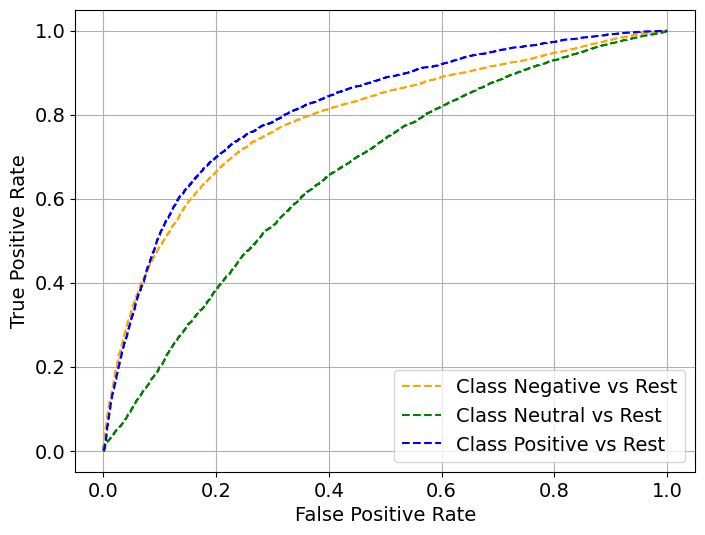

In [ ]:
y_true = climate['Final Label']

label_to_index = {label: i for i, label in enumerate(class_order)}
y_true_indices = np.array([label_to_index[label] for label in y_true])

y_true_bin = label_binarize(y_true_indices, classes=range(n_classes))

fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_true_bin[:, i], y_scores[:, i])

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8, 6))
colors = ['orange', 'green', 'blue']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], linestyle='--', color=color, label=f'Class {class_order1[i]} vs Rest')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('Multiclass_ROC_ASADAraBERT_on_ClimaSentAR.png', dpi=300, bbox_inches='tight')
plt.show()

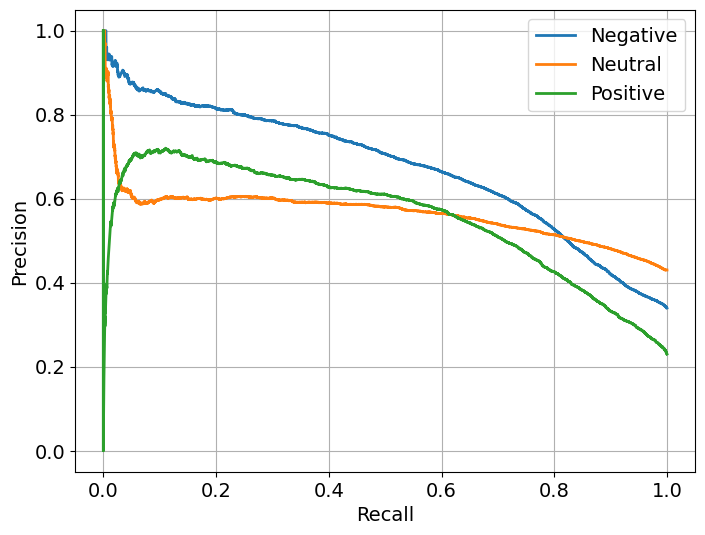

In [ ]:
label_to_index = {label: i for i, label in enumerate(class_order)}
y_true_indices = np.array([label_to_index[label] for label in y_true])

y_true_bin = label_binarize(y_true_indices, classes=range(n_classes))


precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    plt.plot(recall[i], precision[i], lw=2, label=f'{class_order1[i]}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.savefig('Multiclass_Precision-Recall Curve_ASADAraBERT_on_ClimaSentAR.png', dpi=300, bbox_inches='tight')
plt.grid(True)
plt.show()

In [ ]:
climate['Final Label'] = climate['sentiment'].str.lower()
print(classification_report(climate['Final Label'],pred_climate['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.8205    0.1713    0.2834      8140
     neutral     0.4639    0.9379    0.6207     10307
    positive     0.6897    0.1775    0.2823      5510

    accuracy                         0.5025     23957
   macro avg     0.6580    0.4289    0.3955     23957
weighted avg     0.6370    0.5025    0.4283     23957



In [ ]:
pred_climate[f'text'] = climate['text'].values
pred_climate['True Label'] = climate['Final Label'].values

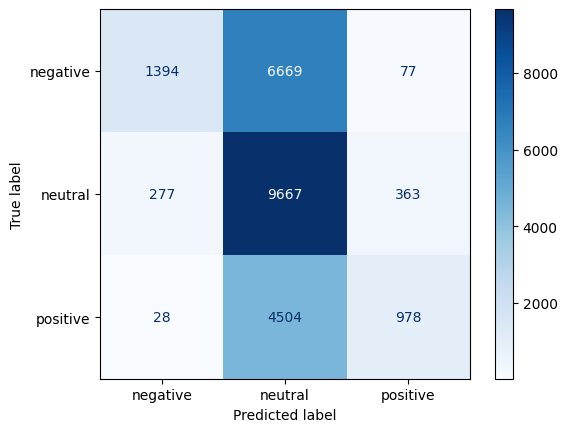

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
   climate['Final Label'],pred_climate['Final Prediction'], cmap = 'Blues')
plt.show()

In [ ]:
pred_climate.to_excel('ASAD-Climate.xlsx', index = False)